# Trading Bot Application - Coding Practice

## List vs Dictionaries

In [3]:
# --- 1. LISTS ---
# A list is just a sequence of items, separated by commas, wrapped in square brackets [ ].
# You access them by their order (index), starting at 0.

my_stock_list = ["AAPL", "MSFT", "GOOGL"]
print("First stock in list:", my_stock_list[0])
print("Second stock in list:", my_stock_list[1])
print("Third stock in list:", my_stock_list[2])

First stock in list: AAPL
Second stock in list: MSFT
Third stock in list: GOOGL


In [6]:
# --- 2. DICTIONARIES ---
# A dictionary uses curly braces { }. Instead of just items, it has "Key: Value" pairs.
# Think of it like a real dictionary: you look up a word (key) to get the definition (value).

my_stock_dict = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Google": "GOOGL"
}
print("Apple's ticker is:", my_stock_dict["Apple"])
print("Microsoft's ticker is:", my_stock_dict["Microsoft"])
print("Google's ticker is:", my_stock_dict["Google"])

Apple's ticker is: AAPL
Microsoft's ticker is: MSFT
Google's ticker is: GOOGL


### Bot's Configuration Structure

In [14]:
# This is a simplified version of what is in your trading bot code:

APPROVED_PAIRS = {
    "US_RETAIL_DUOPOLY": {
        "ticker_a": "LOW",
        "ticker_b": "HD",
        "name": "Lowe's vs Home Depot"
    },
    "US_PAYMENTS": {
        "ticker_a": "V",
        "ticker_b": "MA",
        "name": "Visa vs Mastercard"
    },
    "US_TECH": {
        "ticker_a": "AAPL",
        "ticker_b": "MSFT",
        "name": "Apple vs Microsoft"
    }
}

# How to access data inside this "nested" dictionary:
# First, grab the specific pair you want:

retail_pair = APPROVED_PAIRS["US_RETAIL_DUOPOLY"]
print("Retail Pair Data:", retail_pair)

# Then, grab the specific piece of info from inside that pair:
first_ticker = retail_pair["ticker_a"]
print("The first ticker in the retail pair is:", first_ticker)

# Or, do it all in one step by chaining the keys:
print("The name of the payments pair is:", APPROVED_PAIRS["US_PAYMENTS"]["name"])
print("The name of the payments pair is:", APPROVED_PAIRS["US_TECH"]["name"])

Retail Pair Data: {'ticker_a': 'LOW', 'ticker_b': 'HD', 'name': "Lowe's vs Home Depot"}
The first ticker in the retail pair is: LOW
The name of the payments pair is: Visa vs Mastercard
The name of the payments pair is: Apple vs Microsoft


### How the Bot Uses This Structure (Looping)

In [15]:
# The .items() command breaks the dictionary down so the loop can grab
# the Key (pair_id) and the Value (details) one by one.

for pair_id, details in APPROVED_PAIRS.items():
    print(f"--- Now scanning: {pair_id} ---")

    # We pull out the specific tickers from the 'details' dictionary
    t_a = details['ticker_a']
    t_b = details['ticker_b']
    pair_name = details['name']

    print(f"I am preparing to compare {t_a} against {t_b}.")
    print(f"This trade is officially called: {pair_name}")
    print("Moving to next pair...\n")

--- Now scanning: US_RETAIL_DUOPOLY ---
I am preparing to compare LOW against HD.
This trade is officially called: Lowe's vs Home Depot
Moving to next pair...

--- Now scanning: US_PAYMENTS ---
I am preparing to compare V against MA.
This trade is officially called: Visa vs Mastercard
Moving to next pair...

--- Now scanning: US_TECH ---
I am preparing to compare AAPL against MSFT.
This trade is officially called: Apple vs Microsoft
Moving to next pair...



## Downloading Data from External

In [21]:
import yfinance as yf

# We give yfinance a LIST of tickers (notice the square brackets [ ])

tickers_to_download = ["LOW", "HD"]
print("Downloading data from Yahoo Finance...")

# Download 6 months of data

raw_data = yf.download(tickers_to_download, period="6mo")

# The data downloaded contains Open, High, Low, Close, and Volume.
prices = raw_data['Close'].dropna()

print("\nSuccess! Here are the last 5 days of closing prices:")
print(prices.tail())

[*********************100%***********************]  2 of 2 completed


Success! Here are the last 5 days of closing prices:
Ticker              HD         LOW
Date                              
2026-05-11  311.399994  226.059998
2026-05-12  310.459991  224.520004
2026-05-13  302.549988  220.449997
2026-05-14  304.350006  223.610001
2026-05-15  297.510010  218.419998


In [22]:
# From our previous cell, 'prices' contains 6 months of data for LOW and HD.
# It looks like a table with two columns. Let's separate them.

# 1. Split the table into two separate Pandas "Series" (which are basically single lists)

stock_a = prices["LOW"]
stock_b = prices["HD"]

print("--- Data Split Successful ---")
print("Here are the last 3 days of Lowe's (LOW):")
print(stock_a.tail(3))
print("\nHere are the last 3 days of Home Depot (HD):")
print(stock_b.tail(3))

# 2. Grab the very last price from each list (today's current price)
# In Pandas, .iloc[-1] means "Index Location: the very last item"

latest_price_a = stock_a.iloc[-1]
latest_price_b = stock_b.iloc[-1]

print("\n--- Latest Prices Extracted ---")
print(f"Current price of LOW: ${latest_price_a:.2f}")
print(f"Current price of HD: ${latest_price_b:.2f}")

--- Data Split Successful ---
Here are the last 3 days of Lowe's (LOW):
Date
2026-05-13    220.449997
2026-05-14    223.610001
2026-05-15    218.419998
Name: LOW, dtype: float64

Here are the last 3 days of Home Depot (HD):
Date
2026-05-13    302.549988
2026-05-14    304.350006
2026-05-15    297.510010
Name: HD, dtype: float64

--- Latest Prices Extracted ---
Current price of LOW: $218.42
Current price of HD: $297.51


In [23]:
# 1. Calculate the "Hedge Ratio"
# This tells us how many shares of HD we need to balance 1 share of LOW.
# (If LOW is $200 and HD is $300, the ratio is 0.66)

hedge_ratio = latest_price_a / latest_price_b

# 2. Calculate the "Spread" for the entire 6 months
# We are creating a brand new list of numbers.
# It represents: "Lowe's price MINUS Home Depot's price (multiplied by the ratio)"

spread_series = stock_a - (hedge_ratio * stock_b)

# 3. Calculate the "Z-Score"
# This is the most complex math in the bot.
# It converts the dollar gap into a "Standard Deviation" score.

z_score_series = (spread_series - spread_series.mean()) / spread_series.std()

# 4. Grab today's current Z-Score
current_z = z_score_series.iloc[-1]

print(f"Hedge Ratio: {hedge_ratio:.4f}")
print(f"Current Z-Score: {current_z:.2f}")

if current_z >= 2.0:
    print("\n🚨 SIGNAL: The stocks have diverged too much! (SELL the high one, BUY the low one)")
elif current_z <= -2.0:
    print("\n🚨 SIGNAL: The gap has collapsed too much! (BUY the high one, SELL the low one)")
else:
    print("\n🛑 NO SIGNAL: The stocks are behaving normally and moving together.")

Hedge Ratio: 0.7342
Current Z-Score: 1.40

🛑 NO SIGNAL: The stocks are behaving normally and moving together.


## Visualisation

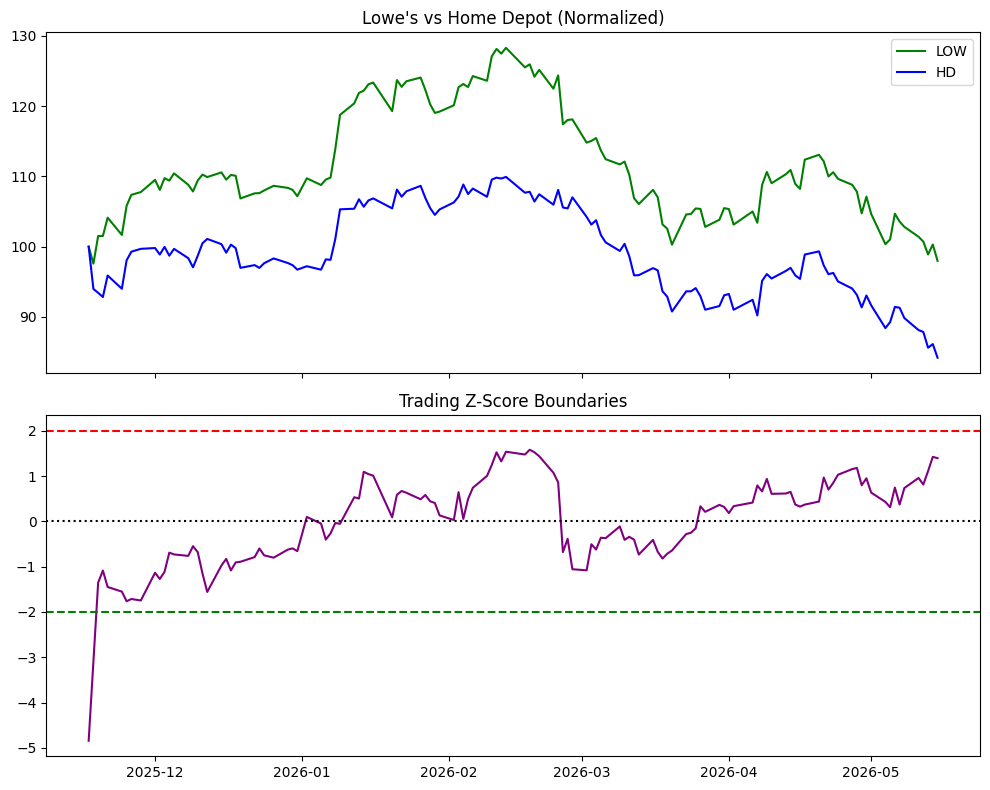

In [24]:
import matplotlib.pyplot as plt

# Create a figure with two subplots (one on top of the other)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Subplot 1: The Raw Stock Prices ---
# We normalize them to 100 so they start at the same point for easier comparison

norm_a = (stock_a / stock_a.iloc[0]) * 100
norm_b = (stock_b / stock_b.iloc[0]) * 100

ax1.plot(norm_a, label="LOW", color='green')
ax1.plot(norm_b, label="HD", color='blue')
ax1.set_title("Lowe's vs Home Depot (Normalized)")
ax1.legend()

 # --- Subplot 2: The Z-Score (The Rubber Band) ---

ax2.plot(z_score_series, color='purple', label="Z-Score")
ax2.axhline(2.0, color='red', linestyle='--')   # Sell Line
ax2.axhline(-2.0, color='green', linestyle='--') # Buy Line
ax2.axhline(0, color='black', linestyle=':')      # The Middle
ax2.set_title("Trading Z-Score Boundaries")

plt.tight_layout()
plt.show()